<a href="https://colab.research.google.com/github/Thanseer-S/DSA_2026/blob/main/CLASSIFICATION_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df = pd.read_csv('/content/titanic_dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [23]:
df.set_index('PassengerId', inplace=True)
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [25]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [26]:
df.shape

(891, 11)

In [27]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,687


In [28]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [29]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [30]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,0


In [31]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[column] >= lower) & (df[column] <= upper)]
    return df

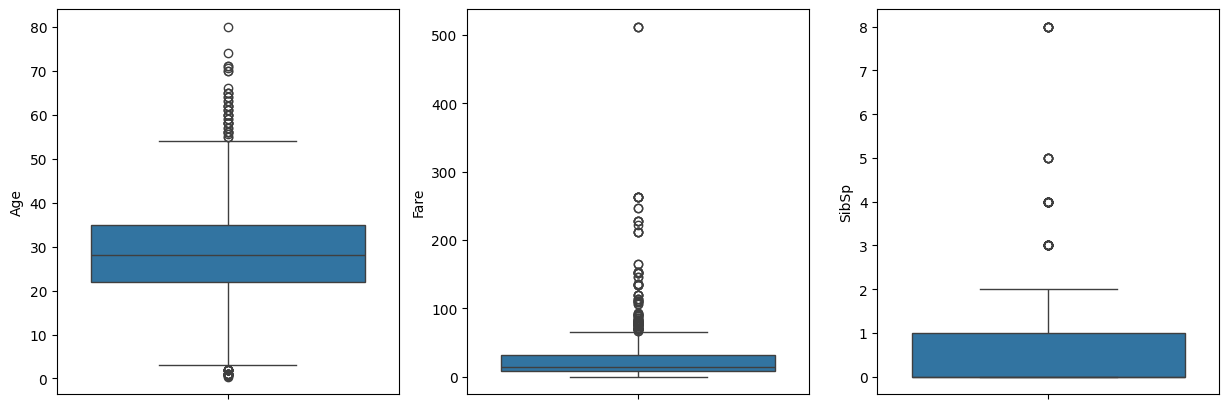

In [32]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.boxplot(y=df['Age'])

plt.subplot(1,3,2)
sns.boxplot(y=df['Fare'])

plt.subplot(1,3,3)
sns.boxplot(y=df['SibSp'])

plt.show()

In [33]:
df = remove_outliers(df,'Age')
df = remove_outliers(df,'Fare')
df = remove_outliers(df,'SibSp')

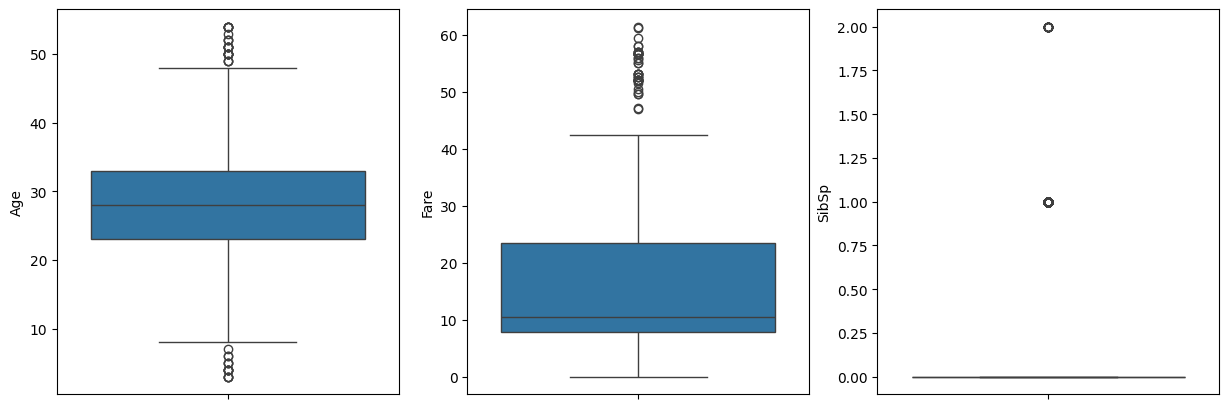

In [34]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.boxplot(y=df['Age'])

plt.subplot(1,3,2)
sns.boxplot(y=df['Fare'])

plt.subplot(1,3,3)
sns.boxplot(y=df['SibSp'])

plt.show()

In [35]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [36]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
        test_size=0.2,
            random_state=42
            )

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [39]:
from sklearn.metrics import accuracy_score

In [40]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

acc_lr = accuracy_score(y_test, pred_lr)

print("Logistic Regression Accuracy:", acc_lr)

Logistic Regression Accuracy: 0.7898550724637681


In [41]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

acc_knn = accuracy_score(y_test, pred_knn)

print("KNN Accuracy:", acc_knn)

KNN Accuracy: 0.8115942028985508


In [42]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(y_test, pred_dt)

print("Decision Tree Accuracy:", acc_dt)

Decision Tree Accuracy: 0.7681159420289855


In [43]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, pred_rf)

print("Random Forest Accuracy:", acc_rf)

Random Forest Accuracy: 0.8333333333333334


In [44]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train, y_train)

pred_svm = svm.predict(X_test)

acc_svm = accuracy_score(y_test, pred_svm)

print("SVM Accuracy:", acc_svm)

SVM Accuracy: 0.782608695652174


In [45]:
results = pd.DataFrame({
    'Model':['Logistic Regression',
             'KNN',
             'Decision Tree',
             'Random Forest',
             'SVM'],
    'Accuracy':[acc_lr,
                acc_knn,
                acc_dt,
                acc_rf,
                acc_svm]
})

print(results)

IndentationError: unexpected indent (1218735679.py, line 14)

In [46]:
best_model = results.loc[results['Accuracy'].idxmax()]

print("Best Model:")
print(best_model)

NameError: name 'results' is not defined